## EDA part 1. 
Part 1 — Data profiling (what you just finished): <br>

Shape — how many rows and columns<br>
Data types — are dates actually dates, numbers actually numbers<br>
Missing values — where are the gaps<br>
Duplicates — is anything repeated<br>
Distributions — value_counts on categorical columns<br>
Summary statistics — describe() for min, max, mean<br>

In [1]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import seaborn as sns
print('All libraries imported successfully! ✅')
print(pd.__version__)
print(numpy.__version__)
print(sns.__version__)
print(plt.matplotlib.__version__)    


All libraries imported successfully! ✅
3.0.2
2.4.4
0.13.2
3.10.9


## connect to PostgreSQL

In [2]:
import sqlalchemy

engine = sqlalchemy.create_engine('postgresql://postgres:gg@localhost:5432/techsales_mx')

df = pd.read_sql('SELECT * FROM sales_orders', engine)
df.head()
df.shape
df.info()
df.columns




<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      2000 non-null   str    
 1   customer_id   2000 non-null   int64  
 2   rep_id        2000 non-null   int64  
 3   product_id    2000 non-null   int64  
 4   order_date    2000 non-null   object 
 5   units         2000 non-null   int64  
 6   unit_price    2000 non-null   float64
 7   revenue       2000 non-null   float64
 8   cost          2000 non-null   float64
 9   profit        2000 non-null   float64
 10  profit_pct    2000 non-null   float64
 11  status        2000 non-null   str    
 12  days_to_ship  2000 non-null   int64  
 13  region        2000 non-null   str    
dtypes: float64(5), int64(5), object(1), str(3)
memory usage: 218.9+ KB


Index(['order_id', 'customer_id', 'rep_id', 'product_id', 'order_date',
       'units', 'unit_price', 'revenue', 'cost', 'profit', 'profit_pct',
       'status', 'days_to_ship', 'region'],
      dtype='str')

## Profile our Data

In [3]:
print('=== SHAPE ===')
print(f"{df.shape[0]} rows and {df.shape[1]} columns")

print("\n===DATA TYPES ===")
print(df.dtypes)


print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_pct})

print(missing_df[missing_df['Missing Values'] > 0])
print("no missing values" if missing.sum() == 0 else " ")

print("\n=== NUMERIC SUMMARY ===")
df.describe().round(2)



=== SHAPE ===
2000 rows and 14 columns

===DATA TYPES ===
order_id            str
customer_id       int64
rep_id            int64
product_id        int64
order_date       object
units             int64
unit_price      float64
revenue         float64
cost            float64
profit          float64
profit_pct      float64
status              str
days_to_ship      int64
region              str
dtype: object

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []
no missing values

=== NUMERIC SUMMARY ===


,customer_id,rep_id,product_id,units,unit_price,revenue,cost,profit,profit_pct,days_to_ship
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,247.23,3.02,5.52,8.06,5849.65,45632.69,25075.42,20557.27,0.45,5.60
std,145.35,1.42,2.88,4.36,7490.37,68559.88,37964.50,31277.12,0.06,2.86
min,1.00,1.00,1.00,1.00,590.00,590.00,272.91,212.74,0.35,1.00
25%,118.75,2.00,3.00,4.00,1490.00,7670.00,4292.69,3548.59,0.40,3.00
50%,244.00,3.00,5.00,8.00,1990.00,18320.00,10157.83,8300.54,0.45,6.00
75%,371.00,4.00,8.00,12.00,8490.00,45370.00,24701.97,20220.51,0.50,8.00
max,500.00,5.00,10.00,15.00,25990.00,389850.00,237994.62,211345.31,0.55,10.00


In [4]:
# Step 2 — explore categorical columns
print("=== STATUS breakdown ===")
print(df['status'].value_counts())
print(f"\nUnique statuses: {df['status'].unique()}")

print("\n=== REGION breakdown ===")
print(df['region'].value_counts())

print("\n=== TOP 5 PRODUCTS by order count ===")
print(df['product_id'].value_counts().head())

print("\n=== DATE RANGE ===")
print(f"Earliest order: {df['order_date'].min()}")
print(f"Latest order:   {df['order_date'].max()}")
print(f"Date type:      {df['order_date'].dtype}")

=== STATUS breakdown ===
status
Completed    1420
Pending       292
Cancelled     288
Name: count, dtype: int64

Unique statuses: <StringArray>
['Completed', 'Pending', 'Cancelled']
Length: 3, dtype: str

=== REGION breakdown ===
region
Estado de México    414
CDMX Centro         412
Guadalajara         410
CDMX Norte          390
CDMX Sur            374
Name: count, dtype: int64

=== TOP 5 PRODUCTS by order count ===
product_id
2     218
8     207
10    206
5     204
3     203
Name: count, dtype: int64

=== DATE RANGE ===
Earliest order: 2022-01-01
Latest order:   2024-12-31
Date type:      object


In [5]:
df['order_date'] = pd.to_datetime(df['order_date'])

print(f"order date dtype: {df['order_date'].dtype}")
df['order_date'].head().tolist()

order date dtype: datetime64[s]


[Timestamp('2023-01-23 00:00:00'),
 Timestamp('2023-02-25 00:00:00'),
 Timestamp('2023-06-04 00:00:00'),
 Timestamp('2023-02-22 00:00:00'),
 Timestamp('2024-09-17 00:00:00')]

### Extract Year, Month, Month name. sych as in SQL

In [6]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month 
df['month_name'] = df['order_date'].dt.strftime('%b %Y')
print(df[['order_date', 'year', 'month', 'month_name']].head())


  order_date  year  month month_name
0 2023-01-23  2023      1   Jan 2023
1 2023-02-25  2023      2   Feb 2023
2 2023-06-04  2023      6   Jun 2023
3 2023-02-22  2023      2   Feb 2023
4 2024-09-17  2024      9   Sep 2024


In [7]:
# Step 3 — full data quality report
print("=== DUPLICATE ROWS ===")
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

print("\n=== UNIQUE VALUES per categorical column ===")
for col in ['status', 'region', 'product_id', 'rep_id']:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n=== REVENUE sanity check ===")
print(f"Negative revenue rows: {(df['revenue'] < 0).sum()}")
print(f"Zero revenue rows:     {(df['revenue'] == 0).sum()}")
print(f"Total revenue:         ${df['revenue'].sum():,.2f}")

print("\n=== STATUS distribution ===")
status_counts = df['status'].value_counts()
status_pct = (df['status'].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({'count': status_counts, 'pct': status_pct}))

=== DUPLICATE ROWS ===
Duplicate rows: 0

=== UNIQUE VALUES per categorical column ===
status: 3 unique values
region: 5 unique values
product_id: 10 unique values
rep_id: 5 unique values

=== REVENUE sanity check ===
Negative revenue rows: 0
Zero revenue rows:     0
Total revenue:         $91,265,380.00

=== STATUS distribution ===
           count   pct
status                
Completed   1420  71.0
Pending      292  14.6
Cancelled    288  14.4


In [8]:
print("=== all years ===")
print(df['status'].value_counts())

print("=== 2024 only ===")
df_2024 = df[df['year']== 2024]
print(df_2024['status'].value_counts())



=== all years ===
status
Completed    1420
Pending       292
Cancelled     288
Name: count, dtype: int64
=== 2024 only ===
status
Completed    483
Pending      100
Cancelled     96
Name: count, dtype: int64


## EDA Part 2: 
Part 2 — Exploratory analysis (where we're going now): <br>

Group by and aggregate — revenue by rep, orders by region<br>
Trends over time — monthly revenue patterns<br>
Correlations — does units sold correlate with profit margin<br>
Outliers — which orders are unusually large or small<br>
Relationships — which products perform best in which regions<br>

In [9]:
rep_revenue = df.groupby('rep_id')['revenue'].sum().sort_values(ascending=False)
print(rep_revenue)

rep_id
2    20512660.0
5    18448370.0
3    17764580.0
4    17428460.0
1    17111310.0
Name: revenue, dtype: float64


## pull all data, all tables in our database. 
- reps 
- products 
- customers 
- suppliers.

In [10]:
df_reps = pd.read_sql('SELECT * FROM reps', engine)
df_products = pd.read_sql('SELECT * FROM products', engine)
df_customers = pd.read_sql('SELECT * FROM customers', engine)
df_suppliers = pd.read_sql('SELECT * FROM suppliers', engine)

print(f'reps: {df_reps.shape}')
print(f"products: {df_products.shape }")
print(f"customers: {df_customers.shape }")
print(f"suppliers: {df_suppliers.shape }")




reps: (5, 7)
products: (10, 7)
customers: (500, 8)
suppliers: (6, 7)


In [11]:

df_reps.head()

,rep_id,rep_name,hire_date,region,annual_quota,base_salary,manager
0,1,Ana Torres,2019-03-01,CDMX Norte,8000000.0,45000.0,Ricardo Fuentes
1,2,Carlos Méndez,2020-07-15,Estado de México,7500000.0,42000.0,Ricardo Fuentes
2,3,Sofía Ramírez,2018-11-20,CDMX Sur,9000000.0,48000.0,Ricardo Fuentes
3,4,Diego López,2021-01-10,Guadalajara,8500000.0,44000.0,Ricardo Fuentes
4,5,Valentina Cruz,2022-05-03,CDMX Centro,6500000.0,38000.0,Ricardo Fuentes


In [12]:
df_merged = df.merge(df_reps[['rep_id' ,'rep_name', 'annual_quota' ]],
            on = 'rep_id', how='left')

verify the merge

In [13]:
print(f"original rows:{df.shape[0]}")
print(f"after merge: {df_merged.shape[0]}")
print(f"new columns: {[c for c in df_merged.columns if c not in df.columns]}")

original rows:2000
after merge: 2000
new columns: ['rep_name', 'annual_quota']


Clash of region, in both data sets

In [14]:
# Rename df to something meaningful
df_sales = df.copy()

# Now redo the merge with the proper name
df_merged = df_sales.merge(df_reps[['rep_id', 'rep_name', 'annual_quota']], 
                            on='rep_id', 
                            how='left')

print(f"df_sales shape:  {df_sales.shape}")
print(f"df_merged shape: {df_merged.shape}")
df_merged[['order_id', 'rep_name', 'region', 'revenue', 'status']].head(5)

df_sales shape:  (2000, 17)
df_merged shape: (2000, 19)


,order_id,rep_name,region,revenue,status
0,ORD-0001,Ana Torres,CDMX Norte,22900.0,Completed
1,ORD-0002,Ana Torres,CDMX Norte,31410.0,Completed
2,ORD-0003,Sofía Ramírez,CDMX Sur,11940.0,Completed
3,ORD-0004,Valentina Cruz,CDMX Centro,19900.0,Completed
4,ORD-0005,Valentina Cruz,CDMX Centro,15120.0,Completed


## 1st. Analysis
- Revenue by Rep

In [15]:
rep_summary = df_merged.groupby('rep_name').agg(
    total_revenue = ('revenue', 'sum'),
    total_orders = ('order_id', 'count'),
    avg_order_value = ('revenue', 'mean'),
    cancel_rate = ('status', lambda x : (x =='Cancelled').sum() / len(x) * 100)).round(2).reset_index()
    
rep_summary = rep_summary.sort_values('total_revenue', ascending=False)
print(rep_summary)

         rep_name  total_revenue  total_orders  avg_order_value  cancel_rate
1   Carlos Méndez     20512660.0           414         49547.49        16.67
4  Valentina Cruz     18448370.0           412         44777.60        14.56
3   Sofía Ramírez     17764580.0           374         47498.88        13.37
2     Diego López     17428460.0           410         42508.44        14.39
0      Ana Torres     17111310.0           390         43875.15        12.82


In [16]:
# Format the output properly
rep_summary['total_revenue'] = rep_summary['total_revenue'].map('${:,.2f}'.format)
rep_summary['avg_order_value'] = rep_summary['avg_order_value'].map('${:,.2f}'.format)
rep_summary['cancel_rate'] = rep_summary['cancel_rate'].map('{:.1f}%'.format)

print("=== REP PERFORMANCE SUMMARY ===")
print(rep_summary.to_string(index=False))

=== REP PERFORMANCE SUMMARY ===
      rep_name  total_revenue  total_orders avg_order_value cancel_rate
 Carlos Méndez $20,512,660.00           414      $49,547.49       16.7%
Valentina Cruz $18,448,370.00           412      $44,777.60       14.6%
 Sofía Ramírez $17,764,580.00           374      $47,498.88       13.4%
   Diego López $17,428,460.00           410      $42,508.44       14.4%
    Ana Torres $17,111,310.00           390      $43,875.15       12.8%


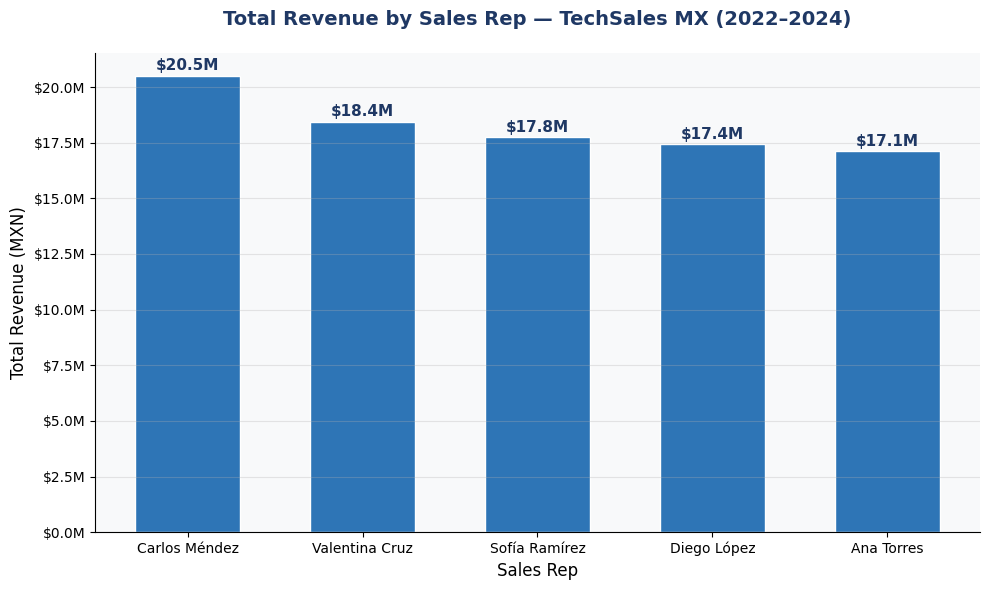

Chart saved as revenue_by_rep.png


In [17]:
import matplotlib.pyplot as plt

# Need numeric values for charting — use original df before formatting
rep_chart = df_merged.groupby('rep_name')['revenue'].sum().sort_values(ascending=False)

# Build the chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(rep_chart.index, rep_chart.values, color='#2E75B6', edgecolor='white', width=0.6)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 100000,
            f'${height/1_000_000:.1f}M',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1F3864')

# Formatting
ax.set_title('Total Revenue by Sales Rep — TechSales MX (2022–2024)', 
             fontsize=14, fontweight='bold', pad=20, color='#1F3864')
ax.set_xlabel('Sales Rep', fontsize=12)
ax.set_ylabel('Total Revenue (MXN)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1_000_000:.1f}M'))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('revenue_by_rep.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as revenue_by_rep.png")

In [18]:
from chart_templates import * 

print('Templates loaded succesfully ✅')


Templates loaded succesfully ✅


## Chart 1
- Revenue by Reps

Saved: chart1_revenue_by_rep.png


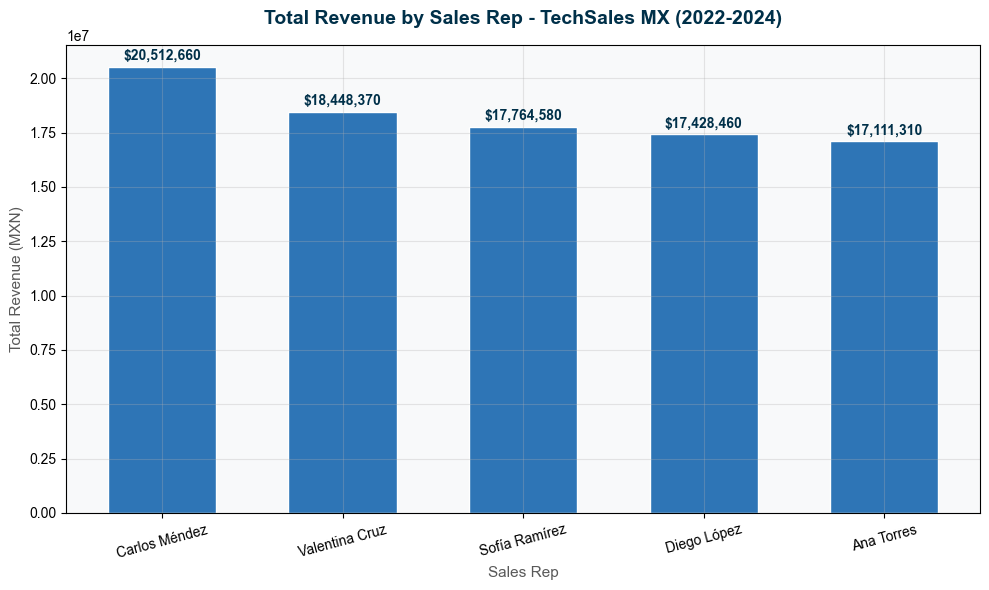

In [19]:
rep_data = df_merged.groupby('rep_name')['revenue'].sum().reset_index()
rep_data = rep_data.sort_values('revenue', ascending=False)

bar_chart( 
    data=rep_data,
    x_col='rep_name',
    y_col='revenue',
    title = "Total Revenue by Sales Rep - TechSales MX (2022-2024)",
    xlabel='Sales Rep',
    ylabel='Total Revenue (MXN)',
    save_as ='chart1_revenue_by_rep.png'          
)





## Chart 2
- line chart: Monthly revenue trend


Saved: chart2_monthly_trend.png


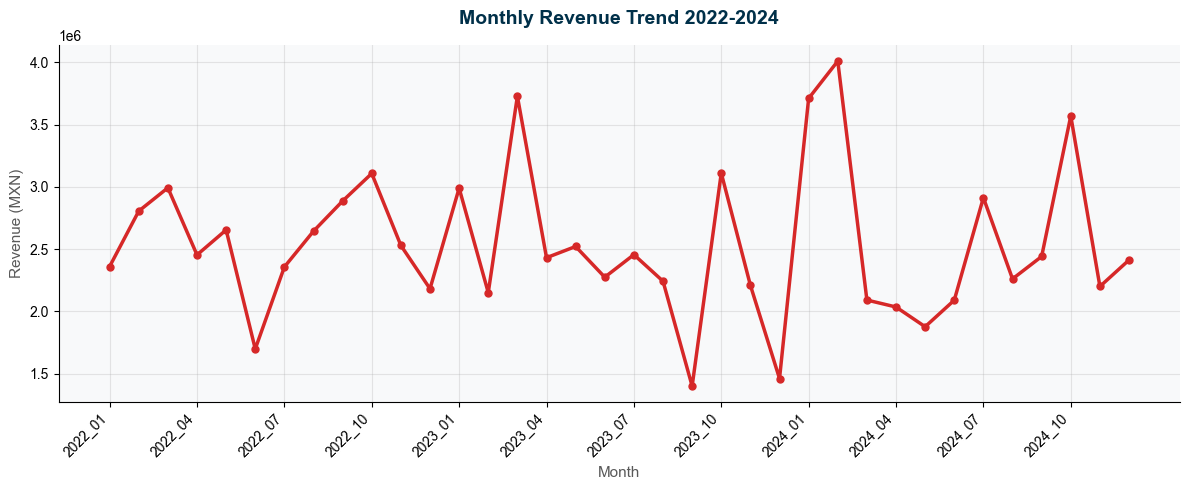

In [26]:
monthly = df_merged.groupby(['year', 'month'])['revenue'].sum().reset_index()
monthly['period'] = monthly['year'].astype(str) + '_' + monthly['month'].astype(str).str.zfill(2)
monthly = monthly.sort_values('period')

line_chart(
    data=monthly,
    x_col='period',
    y_cols='revenue',
    title='Monthly Revenue Trend 2022-2024',
    xlabel='Month',
    ylabel='Revenue (MXN)',
    rotation=45,
    label_every=3,
    colors=[RED],
    save_as='chart2_monthly_trend.png'
)






## Reload the template when changes are made !

In [21]:
import importlib
import chart_templates
importlib.reload(chart_templates)
from chart_templates import *
print("Reloaded ✅")

Reloaded ✅


## Chart 3:
-Scatter plot: units vs revenue correlation

Saved: chart3_units_vs_revenue.png


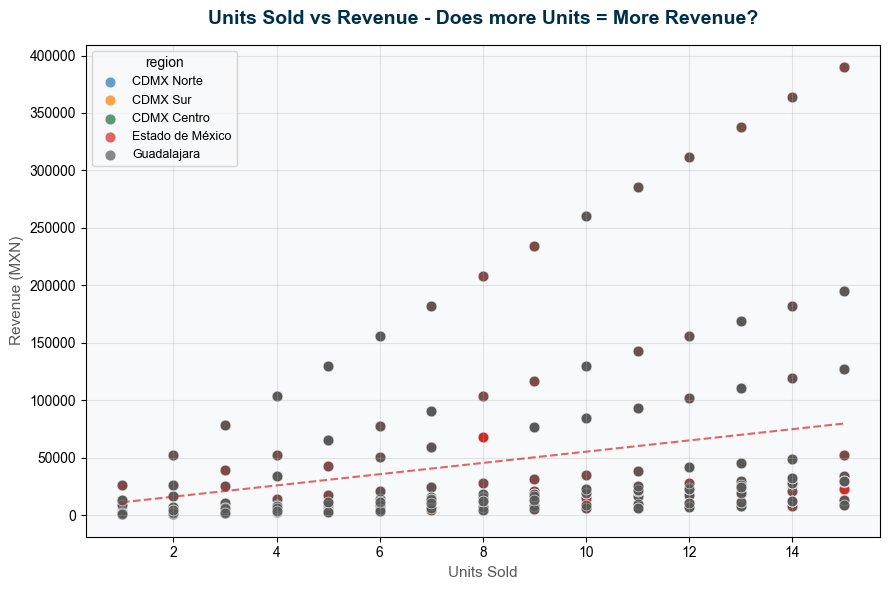

In [22]:
scatter_plot(
    data=df_merged,
    x_col='units',
    y_col='revenue',
    title='Units Sold vs Revenue - Does more Units = More Revenue?',
    xlabel= 'Units Sold',
    ylabel= 'Revenue (MXN)',
    color_col='region',
    save_as= 'chart3_units_vs_revenue.png'
)

## Chart 3B:
- different color, we will color by product

Saved: chart3b_units_revenue_by_product.png


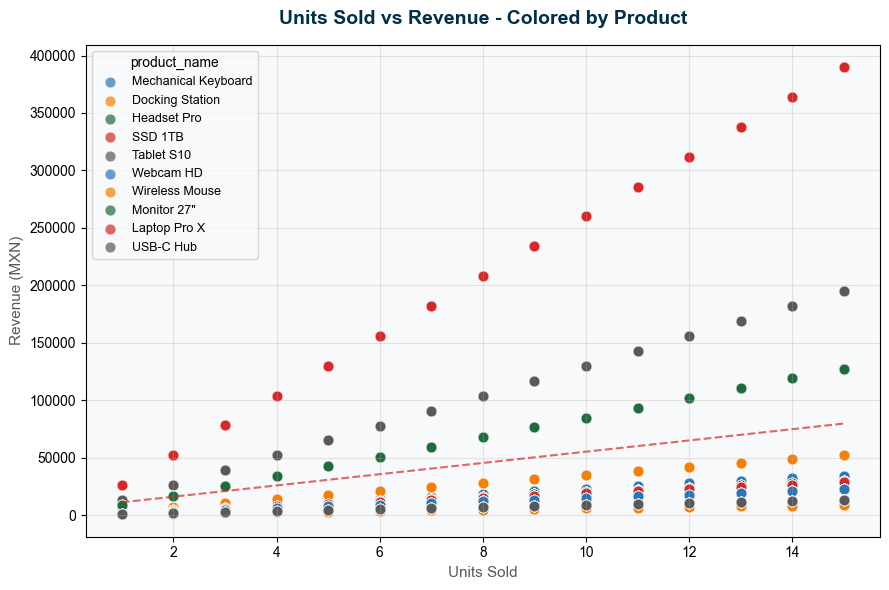

In [ ]:
df_products_merged = df_merged.merge(
    df_products[['product_id','product_name', 'unit_price']],
    on = 'product_id',
    how='left'
)

scatter_plot (
    data=df_products_merged,
    x_col='units',
    y_col = 'revenue',
    title = 'Units Sold vs Revenue - Colored by Product',
    xlabel='Units Sold',
    ylabel='Revenue (MXN)',
    color_col='product_name',
    save_as = 'chart3b_units_revenue_by_product.png'
)


## Chart 4: 
- Histogram : revenue by distribution


Saved: chart4_revenue_distribution.png


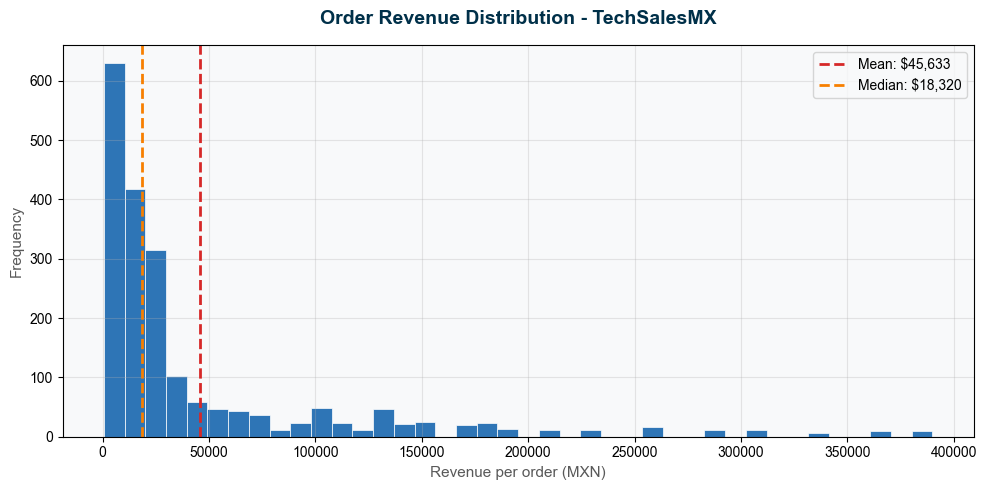

In [24]:
histogram(
    data= df_merged,
    col ='revenue',
    title = 'Order Revenue Distribution - TechSalesMX',
    xlabel = 'Revenue per order (MXN)',
    bins = 40,
    save_as = 'chart4_revenue_distribution.png'
)

"The median order is $18K but the mean is $45K — indicating a right-skewed distribution driven <br>
by high-ticket Laptop Pro X and Tablet S10 orders. Median better represents a typical order while mean <br> 
better reflects overall revenue potential."<br>
- That one sentence in a presentation makes you look like a senior analyst 

## Chart 5 :
- Heatmap - revenue by rep and region
- first build a pivot table


Saved: chart5_heatmap_rep_region.png


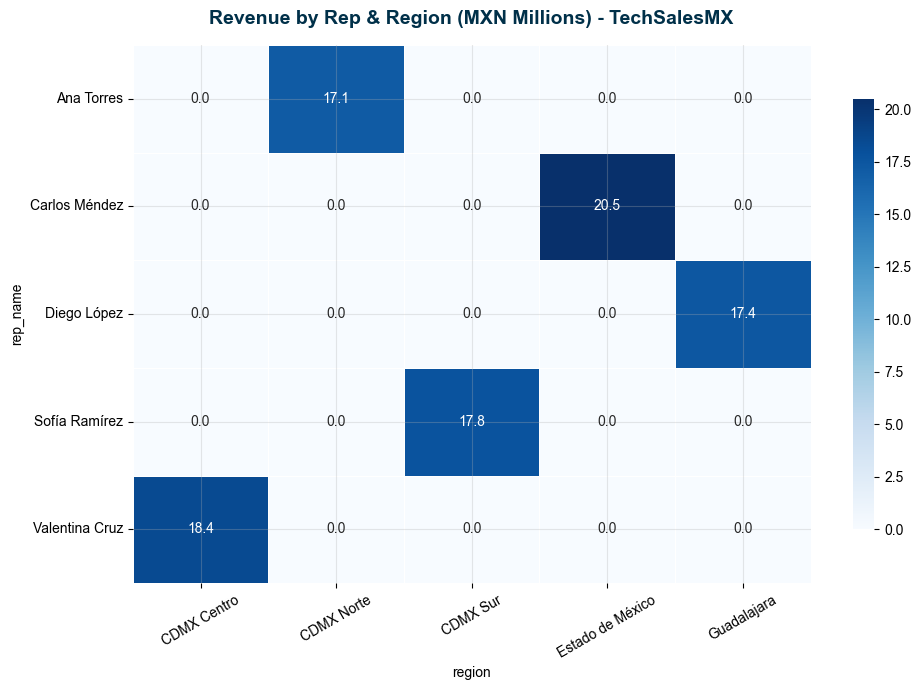

In [25]:
# pivot table just like excel — index is rows, columns is columns, values is what we want to aggregate,
# aggfunc is how we want to aggregate (sum, mean, count, etc)
pivot = df_merged.pivot_table(
    values='revenue',
    index='rep_name',
    columns='region',
    aggfunc='sum'
).fillna(0) #fill in 0 so any NaN values become 0 for better visualization

pivot_millions = pivot / 1_000_000

heatmap(
    data=pivot_millions,
    title = 'Revenue by Rep & Region (MXN Millions) - TechSalesMX',
    fmt='.1f',
    cmap='Blues',
    save_as='chart5_heatmap_rep_region.png'
)





## Chart 6 : 
- box plot - revenue spread by region


Saved: Chart6_boxplot_rev_region.png


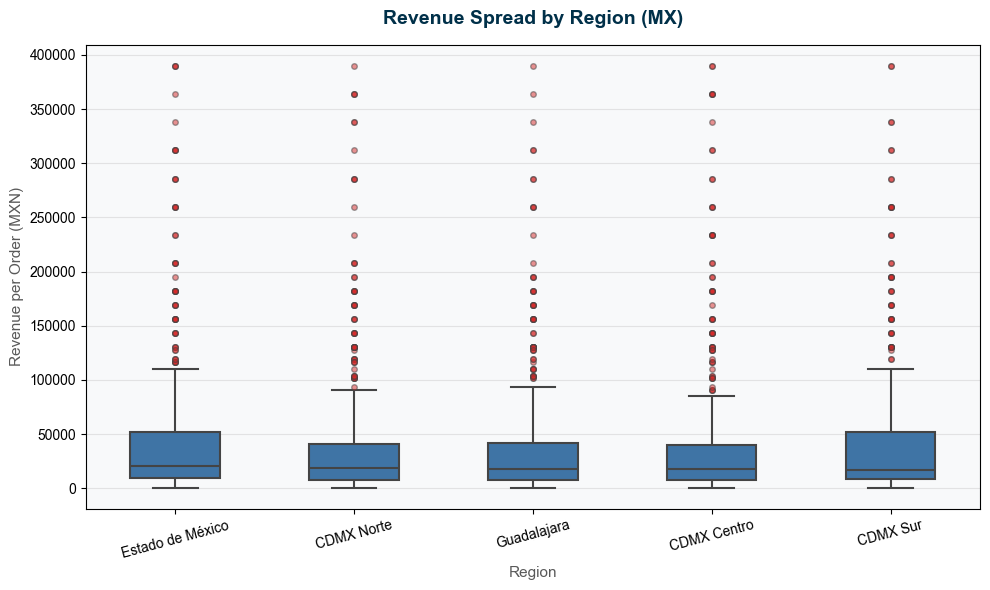

In [28]:
box_plot(
data=df_merged,
x_col='region',
y_col='revenue',
title='Revenue Spread by Region (MX)',
xlabel='Region',
ylabel='Revenue per Order (MXN)',
save_as='Chart6_boxplot_rev_region.png'
)

## Automated Report Generation
- most vital skill
- Now we move to the most important Python skill for your portfolio — automated report generation.<br>
  This is what gets you hired. You're going to write a script that:<br>

- Connects to PostgreSQL
- Pulls and cleans the data
- Calculates all your KPIs
- Exports a formatted Excel file automatically
- Every time you run it — fresh data, fresh report. No manual work.

C:\Projects\YourProject\ <br>
    ├── venv\
    ├── db_connect.py         ← copy in, fill credentials <br>
    ├── venv\
    ├── cleaning_utils.py     ← copy in, use as-is <br>
    ├── venv\
    ├── chart_templates.py    ← copy in, use as-is
    ├── report_template.py    ← copy in, fill YOUR DATA HERE sections <br>
    ├── venv\
    └── analysis.ipynb        ← your notebook <br>
    ├── venv\